In [21]:
!pip install -q yfinance pandas numpy scipy matplotlib seaborn scikit-learn xgboost

# Financial Time Series Smoothing and Prediction using Kalman Filter and ML
### Author: Andreas Katsaounis


## Introduction
Financial time series are inherently noisy, making it difficult to extract meaningful trends from raw price data.
This project is split into 3 parts:
1. Exploratory Data Analysis (EDA) for better understanding the dataset and making insights.
2. Kalman Filter (KF) to smooth stock price data and estimate the underlying latent signal.
3. Machine Learning (ML) models to predict the direction of future price movements.

The dataset contains daily stock data for Apple Inc. (2022–2024), including price-based features such as close, high, low, and derived quantities like returns and volatility.

## Exploratory Data Analysis (EDA)
We first retrieve historical stock data.

In [22]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import jarque_bera
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def get_stock_data(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    return data

df = get_stock_data("AAPL", "2022-01-01", "2024-12-31").reset_index()

[*********************100%***********************]  1 of 1 completed


Then, we construct additional features, such as daily stock range, percentage change (returns), close price differences and rolling volatility of returns.

More precisely, returns are used instead of raw prices in many financial models due to their more stable statistical properties. Additionally, volatility captures the variability of returns and is commonly used as a proxy for market risk.

In [23]:
df.rename(columns={
    'Date': 'date',
    'Close': 'close',
    'High': 'high',
    'Low': 'low',
    'Open': 'open',
    'Volume': 'volume'}, inplace=True)
df['range'] = df['high'] - df['low']
df['price_diff'] = df['close'].diff()
df['returns'] = df['close'].pct_change()
df['volatility'] = df['returns'].rolling(10).std()
df['volatility'] = df['volatility'].fillna(df['volatility'].mean())
df = df.dropna().reset_index(drop=True)
print(df.head(10), '\n')
print(f"Dataset shape: {df.shape}\n")
print(df.describe())

z = df['close'].values

Price        date       close        high         low        open     volume  \
Ticker                   AAPL        AAPL        AAPL        AAPL       AAPL   
0      2022-01-04  175.843292  179.013761  175.275738  178.710417   99310400   
1      2022-01-05  171.165817  176.303140  170.891828  175.755162   94537600   
2      2022-01-06  168.308517  171.537695  167.956243  168.993491   96904000   
3      2022-01-07  168.474838  170.402559  167.359306  169.179387   86709100   
4      2022-01-10  168.494415  168.797760  164.560689  165.451162  106765600   
5      2022-01-11  171.322403  171.420248  167.153837  168.621644   76138300   
6      2022-01-12  171.762741  173.377323  171.067988  172.340075   74805200   
7      2022-01-13  168.494415  172.829330  168.102991  172.007362   84505800   
8      2022-01-14  169.355545  170.050299  167.418029  167.662664   80440800   
9      2022-01-18  166.155716  168.836900  165.774087  167.829007   90956700   

Price      range price_diff   returns v

## Basic EDA plots and insights

The closing price series exhibits clear trends and structural movements over time.
However, short-term fluctuations suggest the presence of noise, making it difficult to directly extract the underlying signal.

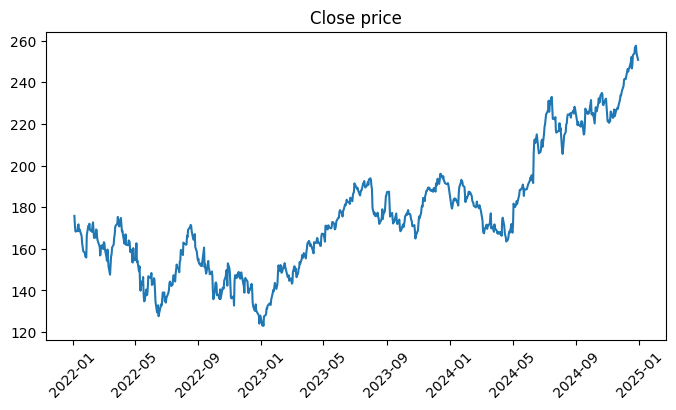

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(df['date'], z)
plt.title("Close price")
plt.xticks(rotation=45)
plt.show()

Returns fluctuate around zero, with most daily changes lying within a relatively narrow range. This behavior is consistent with noisy observations and supports the use of a filtering approach.
The distribution of returns (histogram) appears approximately symmetric and bell-shaped, suggesting a rough alignment with the Gaussian assumption, often used in statistical modeling.

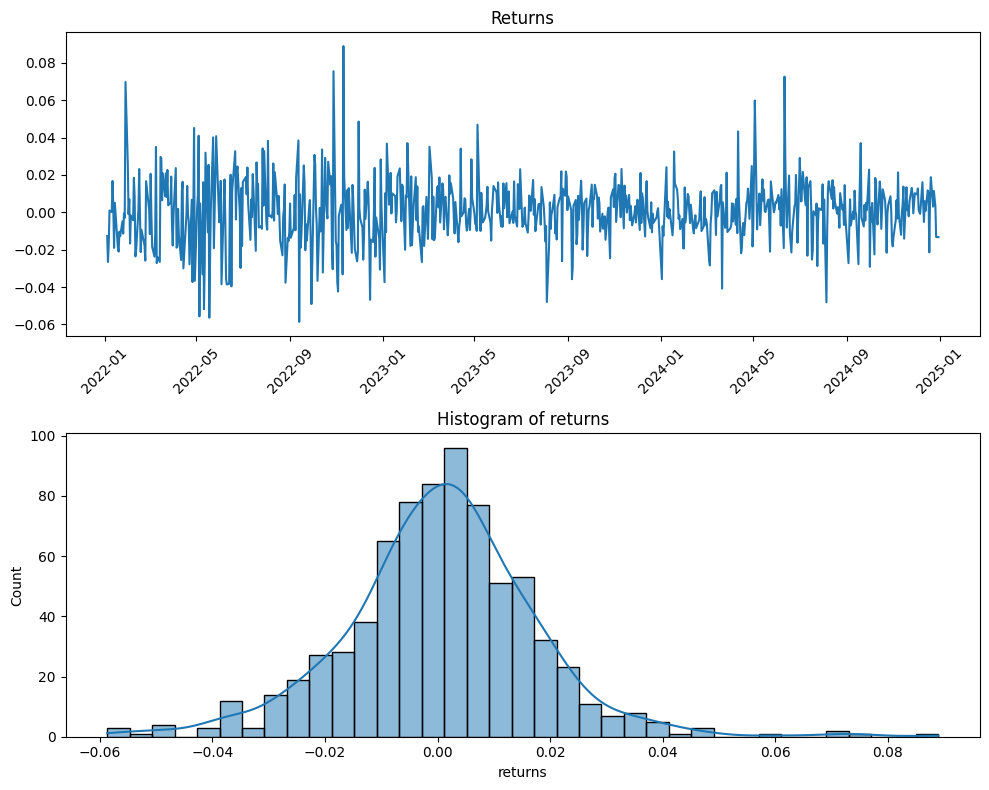

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(10,8))
axes[0].plot(df['date'], df['returns'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title("Returns")

sns.histplot(df['returns'], kde=True, ax=axes[1])
axes[1].set_title("Histogram of returns")

plt.tight_layout()
plt.show()

Volatility varies over time, indicating periods of higher and lower market uncertainty. This motivates the use of time-varying noise parameters ($Q$ and $R$ in Kalman Filter) in the filtering process.

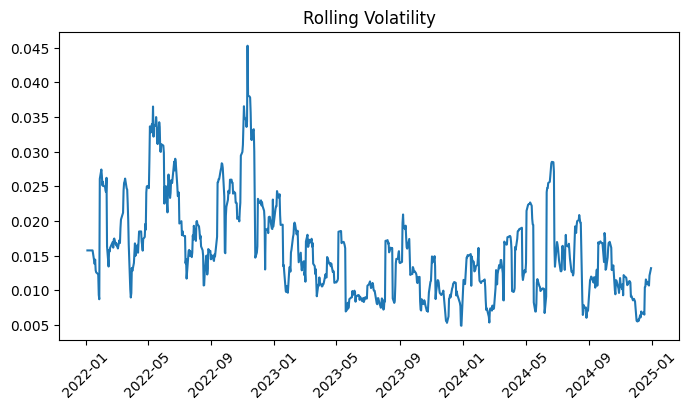

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(df['date'], df['volatility'])
plt.xticks(rotation=45)
plt.title("Rolling Volatility")
plt.show()

## Kalman Filter

Kalman filter (KF) [1] aims to estimate the true underlying state $x_t$ of Close price, assuming that the observed data $z_t$ are noisy measurements of this latent state. Therefore,
$$
x_t = x_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q)
$$
and
$$
z_t = x_t + v_t, \quad v_t \sim \mathcal{N}(0, R).
$$

The parameters $Q$ and $R$ represent the variances of the process noise and measurement noise, respectively, and will play a vital role in our attempt to successfully extract the underlying signal from the raw data.

Intuitively, a small $Q$ implies that the system evolves smoothly over time, leading to more trust in the model prediction. Conversely, a small $R$ indicates that the observations are reliable.

These two quantities determine the Kalman gain, which is the key factor that decides, in each step of the algorithm, whether to trust the prediction of the state or the observed data:
$$
K_t = \frac{P^-_{t}}{P^-_{t} + R},
$$
where $P^-_{t}$ denotes the uncertainty (variance) of the predicted state before incorporating the new observation.

A large $P_t^-$ implies low confidence in the prediction, leading the filter to rely more on the observed data. On the other hand, a large $R$ reduces the influence of the observations, making the model depend more on its internal estimate.

In this project, we let $Q$ and $R$ be non-constant, acknowledging the noisy nature of financial data. We define $R$ based on the daily price range, using $(high - low)^2$ as a proxy for measurement uncertainty. Then, $Q$ is set proportionally to $R$, ensuring that both quantities adapt to market conditions while maintaining a smoother latent estimate.

The initial uncertainty is set to 1.0, reflecting no prior knowledge of the state.

In [27]:
R = (df['range'])**2
alpha = 0.01
Q = alpha * R

def kalman_filter(z, Q, R):
    x_hat = [z[0]]
    P = [1.0]

    for t in range(1, len(z)):
        x_pred = x_hat[t-1]
        P_pred = P[t-1] + Q[t]

        K_k = P_pred / (P_pred + R[t])
        x_new = x_pred + K_k * (z[t] - x_pred)
        P_new = (1 - K_k) * P_pred

        x_hat.append(x_new)
        P.append(P_new)
    return P, x_hat

Plotting the observed and "Kalman" data together, it's easy to see that Kalman estimate is smoother than raw data. Moreover, observing local minima and maxima of the 2 plots, we can conclude that there is a lag in the Kalman estimate, which is due to the way the initial KF algorithm works. Although this lag isn't appropriate for real-time prediction, it is sufficient for denoising the data before feeding it into ML models. (See Appendix for Kalman Smoother, which smooths data without lag.)

Meanwhile, the MSE provides a quantitative indication of how closely the filtered series follows the observed data. A relatively low value suggests that the chosen $Q$ and $R$ achieve a reasonable balance between smoothing and data fidelity.

Furthermore, looking at "Kalman vs observed data" and "Residuals (noise)" plots side-by-side, it is clear that larger residuals often coincide with rapid changes in the observed data, indicating that the filter smooths out abrupt fluctuations.

Error magnitude (MSE): 31.358
Sqrt of MSE: 5.600


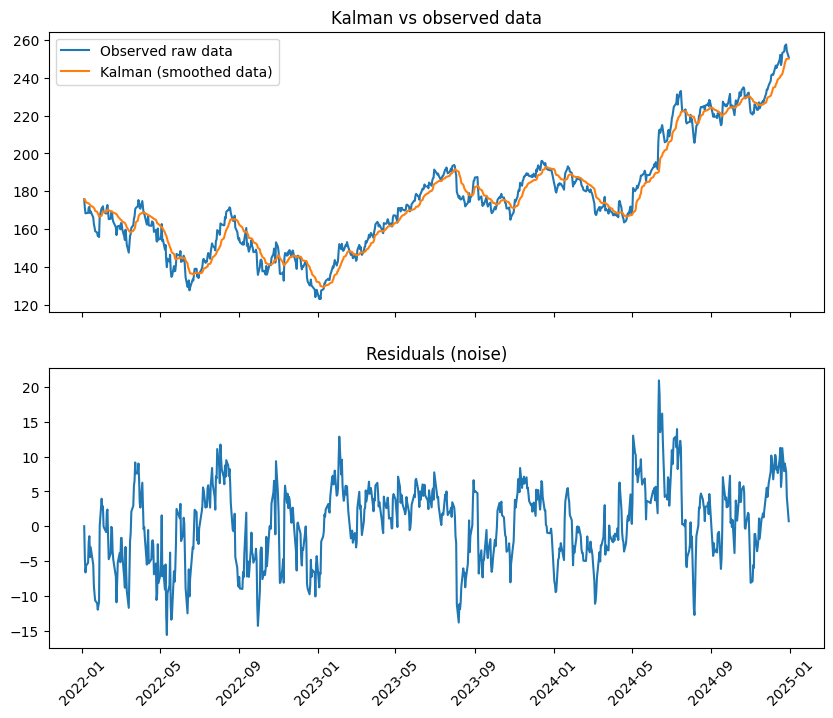

In [28]:
P, x_hat = kalman_filter(z=z, Q=Q, R=R)
residuals = np.array(z) - np.array(x_hat)
residuals_mean = np.mean(residuals)
residuals_std = np.std(residuals)
error_magnitude = np.mean(residuals**2)
root_mse = np.sqrt(error_magnitude)
print(f"Error magnitude (MSE): {error_magnitude:.3f}")
print(f"Sqrt of MSE: {root_mse:.3f}")

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10,8))
axes[0].plot(df['date'], z, label="Observed raw data")
axes[0].plot(df['date'], x_hat, label="Kalman (smoothed data)")
axes[0].legend()
axes[0].set_title("Kalman vs observed data")

axes[1].plot(df['date'], residuals)
axes[1].set_title("Residuals (noise)")

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.show()

To validate the Gaussian noise assumption, it's necessary to check whether the KF's initial assumption, that noise is Gaussian, is met.

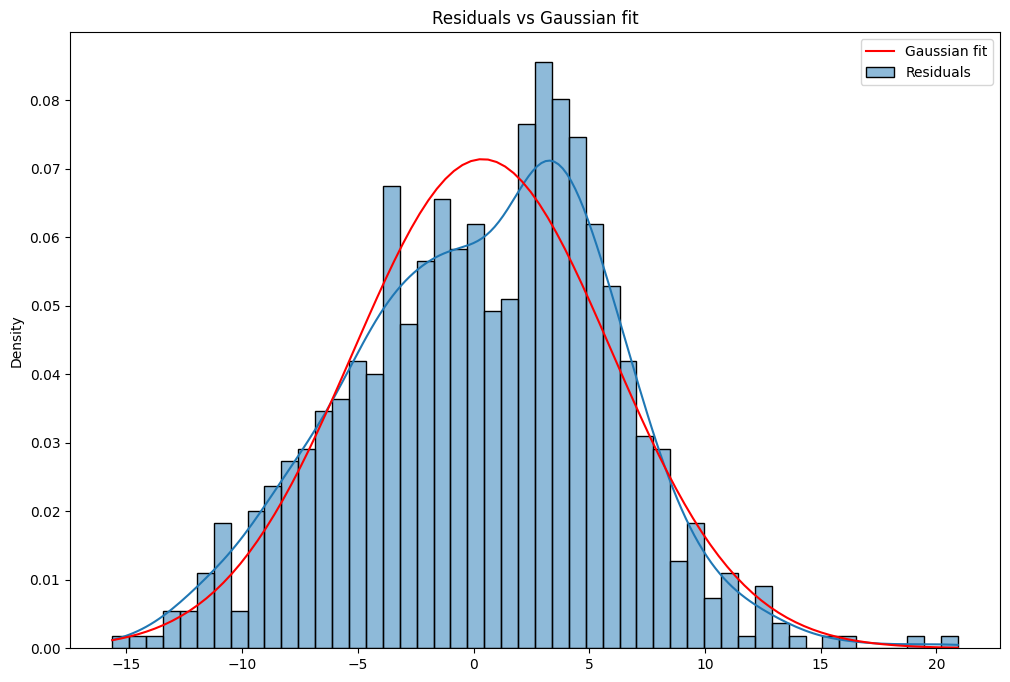

Skewness: -0.089
Approximately symmetric

Kurtosis: -0.077
Close to Gaussian tails


In [29]:
x = np.linspace(min(residuals), max(residuals), 100)
pdf = stats.norm.pdf(x, residuals_mean, residuals_std)

plt.figure(figsize=(12, 8))
sns.histplot(residuals, bins=50, kde=True, stat="density", label="Residuals")
plt.plot(x, pdf, color='red', label="Gaussian fit")
plt.legend()
plt.title("Residuals vs Gaussian fit")
plt.show()

skew_val = skew(residuals).item()
print(f"Skewness: {skew_val:.3f}")

if abs(skew_val) < 0.5:
    print("Approximately symmetric")
elif abs(skew_val) < 1:
    print("Moderate skewness")
else:
    print("High skewness")

kurt_val = kurtosis(residuals).item()
print(f"\nKurtosis: {kurt_val:.3f}")

if abs(kurt_val) < 0.5:
    print("Close to Gaussian tails")
elif kurt_val > 0:
    print("Fat tails (leptokurtic)")
else:
    print("Thin tails (platykurtic)")

We also implement Jarque-Bera test (JB) to verify whether residuals are Gaussian.

In [30]:
jb_stat, p_value = jarque_bera(residuals)

print("Jarque-Bera test")
print(f"JB statistic: {jb_stat:.3f}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.05:
    print("According to Jarque-Bera test, null hypothesis (H_0) is rejected;"
    "data are not Gaussian.")
else:
    print("According to Jarque-Bera test, "
    "null hypothesis (H_0) cannot be rejected.")

Jarque-Bera test
JB statistic: 1.182
p-value: 0.55390
According to Jarque-Bera test, null hypothesis (H_0) cannot be rejected.


The residual analysis suggests that the Gaussian assumption is a reasonable approximation, although not perfectly satisfied, which is common in financial time series.

# Classification for prediction

In the final part, we will utilise classification algorithms (Logistic Regression, Random Forest, XGBoost) in an attempt to predict whether Close price will increase or decrease. Our models will be trained on data from 2022-2023 to predict 2024.

- Logistic Regression is a linear classification model that estimates the probability of a binary outcome using a sigmoid function applied to a linear combination of features. Due to its linear nature, it struggles to capture complex non-linear relationships.

- Random Forest is an ensemble method that builds multiple decision trees on random subsets of the data and aggregates their predictions by majority voting. This reduces overfitting compared to a single decision tree.

- XGBoost (Extreme Gradient Boosting) is a sequential ensemble method where each tree corrects the errors of the previous one using gradient descent on a loss function. It is widely used in tabular data tasks due to its efficiency and predictive power.

# Logistic Regression

Naive baseline accuracy: 0.566
Accuracy: 0.450


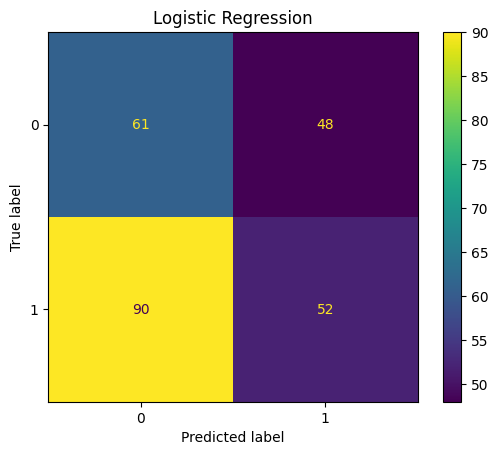

In [31]:
df1 = df.copy()
df1['kf_close'] = x_hat
df1['returns_lag1'] = df1['returns'].shift(1)
df1['volatility_lag1'] = df1['volatility'].shift(1)
df1['residuals'] = residuals
df1['residuals_lag1'] = df1['residuals'].shift(1)
df1['kf_uncertainty'] = P
df1['kf_uncertainty_lag1'] = df1['kf_uncertainty'].shift(1)
df1['direction'] = (df1['returns'] > 0).astype(int)
df1['intraday_momentum'] = df1['close'] - df1['open']
df1['volume_volatility'] = df1['volume'].pct_change().rolling(10).std()
df1['volume_volatility'] = df1['volume_volatility'].fillna(df1['volume_volatility'].mean())
df1['range_lag1'] = df1['range'].shift(1)
df1['intraday_momentum_lag1'] = df1['intraday_momentum'].shift(1)
df1['volume_volatility_lag1'] = df1['volume_volatility'].shift(1)
df1['returns_rolling5'] = df1['returns'].rolling(5).mean().shift(1)
df1['residuals_rolling5'] = df1['residuals'].rolling(5).mean().shift(1)
df1['intraday_momentum5'] = df1['intraday_momentum'].rolling(5).mean().shift(1)
df1['range_rolling5'] = df1['range'].rolling(5).mean().shift(1)
df1 = df1.dropna().reset_index(drop=True)

train_df = df1[df1['date'] < '2024-01-01']
test_df = df1[df1['date'] >= '2024-01-01']

features = ['returns_lag1', 'volatility_lag1', 'residuals_lag1',
            'kf_uncertainty_lag1', 'range_lag1', 'intraday_momentum_lag1',
            'volume_volatility_lag1', 'returns_rolling5', 'residuals_rolling5',
            'intraday_momentum5', 'range_rolling5']
X_train = train_df[features]
y_train = train_df['direction']

X_test = test_df[features]
y_test = test_df['direction']

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

naive_acc = y_test.mean()
print(f"Naive baseline accuracy: {naive_acc:.3f}")

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred_lr = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")

cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression")
plt.show()

We observe that the model's accuracy $(45.0\%)$ is less than naive baseline accuracy $(56.6\%)$, that is the probability of correct prediction, assuming that stock always increases. Moreover, based on the Confusion Matrix, we conclude that our model predicts better when stock increases $(\frac{61}{61+48} = 55.96\%)$, than when it decreases $(\frac{52}{52+90} = 36.62\%)$. On the whole, Logistic Regression doesn't provide a good prediction for financial data, due to its linear nature, leading us to apply other classification algorithms.

# Random forest

Accuracy: 0.470


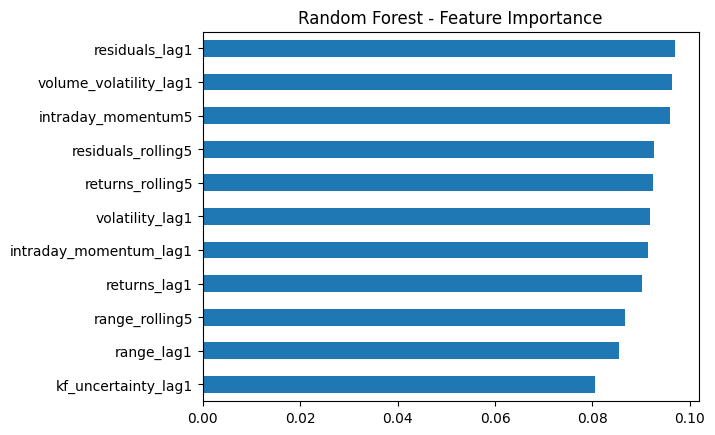

In [32]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred_rf = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")

importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')
plt.title("Random Forest - Feature Importance")
plt.show()

The model's accuracy $(45.8\%)$ is still less than naive baseline accuracy $(56.6\%)$, meaning that it fails to effectively make predictions. However, looking at "Feature Importance" diagram, we can conclude that features share approximately the same importance for the model, suggesting that no single feature dominates the prediction.

# XGBoost

In [33]:
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

print(f"XGB Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")

XGB Accuracy: 0.466


Even though XGBoost is more complex than Random Forest, it achieves the lowest accuracy among the three models, remaining below the naive baseline. This is because it uses Gradient Boosting, which tries to correct its predecessors' errors, but, in our case, errors are random noise, meaning that Boosting overfits the dataset's noise.

## Model Comparison

                 Model  Accuracy
0       Naive Baseline  0.565737
1  Logistic Regression  0.450199
2        Random Forest  0.470120
3              XGBoost  0.466135


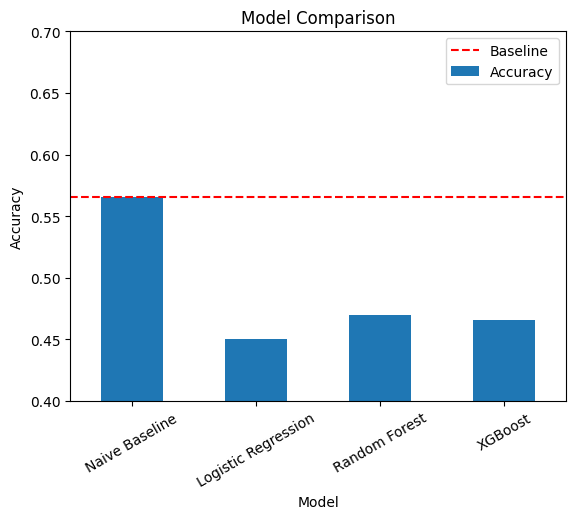

In [34]:
results = pd.DataFrame({
    'Model':    ['Naive Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        naive_acc,
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})
print(results)

results.set_index('Model')['Accuracy'].plot(kind='bar', ylim=(0.4, 0.7))
plt.axhline(naive_acc, color='red', linestyle='--', label='Baseline')
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.legend()
plt.show()

Comparing models' accuracy, we conclude that complexity alone does not imply better prediction. More precisely, XGBoost, the most complex of the models, has the worst accuracy and Logistic Regression, the simplest and linear one, is a bit better. This indicates that technical features alone exhibit no exploitable structure, neither linear nor non-linear, quantitatively confirming the findings of the Kalman Filter analysis.

# Conclusion

In this project, we used Kalman Filter for denoising and feature extraction. We then used these features in 3 different classification models to predict the direction of price movements.

Despite the use of multiple features, none of the models reached or surpassed naive baseline, leading us to conclude that features don't have enough predictive power, due to the absence of exploitable structure in technical features of large-cap stock data, like those of Apple Inc. (AAPL). Therefore, Kalman Filter can be considered as useful for denoising, but the derived features didn't improve the prediction of raw returns, highlighting a mismatch between smooth latent signal and noisy target.

Nevertheless, the feature importance diagram of the Random Forest algorithm is consistent with the weak form of the Efficient Market Hypothesis, which posits that asset prices fully reflect all available technical information, suggesting that additional predictive power may come from sentiment analysis or alternative data sources. To further improve the accuracy of this project, one could also rely on more advanced models, such as neural networks.

# Appendix

# Kalman Smoother

Kalman Smoother (KS) [2] is an algorithm that smooths noisy data. Its difference from KF lies in the fact that in each step it uses the entire dataset of observed data. Therefore, in contrast to KF, it doesn't produce any lag, compared with observed data. However, it isn't appropriate for ML models, due to the use of the whole dataset in each step.

In [35]:
def kalman_smoother(P, x_hat, Q):
    T = len(x_hat)

    x_smooth = np.zeros(T)
    P_smooth = np.zeros(T)
    P_cross = np.zeros(T)
    x_smooth[-1] = x_hat[-1]
    P_smooth[-1] = P[-1]

    for t in range(T-2, -1, -1):
        P_pred = P[t] + Q[t]
        J_t = P[t] / P_pred
        x_smooth[t] = x_hat[t] + J_t*(x_smooth[t+1] - x_hat[t])
        P_smooth[t] = P[t] + (J_t**2)*(P_smooth[t+1] - P_pred)
        P_cross[t+1] = J_t * P_smooth[t+1]
    return x_smooth, P_smooth, P_cross

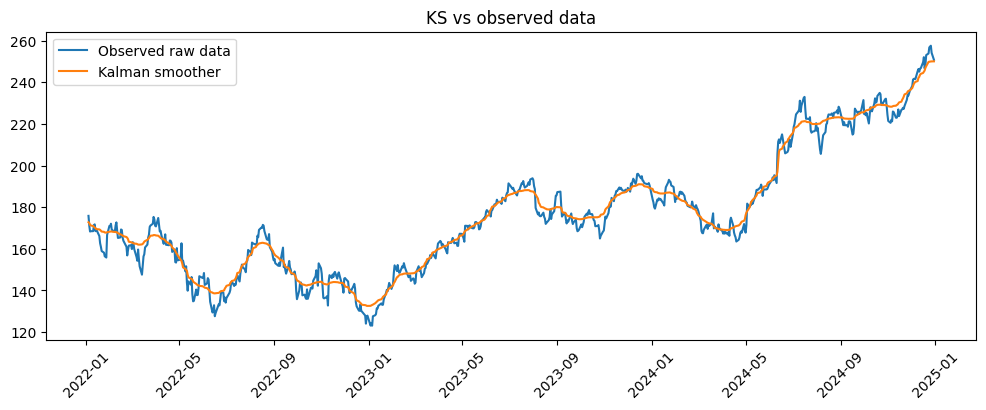

In [36]:
x_hat = np.array(x_hat).flatten()
x_smooth, P_smooth, P_cross = kalman_smoother(P=P, x_hat=x_hat, Q=Q)

plt.figure(figsize=(12, 4))
plt.plot(df['date'], z, label="Observed raw data")
plt.plot(df['date'], x_smooth, label="Kalman smoother")
plt.xticks(rotation=45)
plt.legend()
plt.title("KS vs observed data")
plt.show()

## References
- [1] Welch, G., Bishop, G. (2006). An Introduction to the Kalman Filter.
- [2] Shumway, R.H., Stoffer, D.S. (1982). An approach to time series smoothing and forecasting using the EM algorithm.